<div>
<img src="https://i.ibb.co/v3CvVz9/udd-short.png" width="150"/>
    
</div>


# Machine Learning Avanzado: Laboratorio 02

<br>
    <strong>Universidad del Desarrollo</strong><br>
    <em>Profesor: Tomás Fontecilla </em><br>
    
**Nombre Estudiante(s)**:  
- Cesar Soto
- Cristhian Solís
- Cristian Vasquez


## Introducción  

En este laboratirio se busca aplicar y comparar diferentes técnicas de redes neuronales para abordar un problema de clasificación binaria utilizando el conjunto de datos **"Chihuahuas vs Muffins"**. Este desafío permite explorar el diseño y evaluación de modelos, destacando el uso de redes neuronales convolucionales (CNNs) frente a un Perceptrón Multicapa (MLP). A través de esta comparación, se analizarán las capacidades de las CNNs para identificar patrones visuales complejos.

## Objetivo:

- Comparar el desempeño de un modelo de Perceptrón Multicapa (MLP) con redes convolucionales (CNNs).  
- Diseñar y evaluar tres arquitecturas diferentes de redes convolucionales.  
- Analizar las métricas de rendimiento y justificar las diferencias observadas entre los modelos.  
- Presentar los resultados de manera estructurada en un informe técnico en formato Jupyter Notebook.

## Marco metodológico

En el marco de este laboratorio, se desarrollaron actividades secuenciales que determinaron el marco metodológico guiando el desarrollo del laboratorio:
1. Carga y Preprocesamiento de datos
2. Desarrollo Modelo Perceptrón Multicapa (MLP) 
3. Desarrollo Modelo CNN
4. Comparación de metricas
5. Conclusiones

## 1.- Carga y Preprocesamiento de datos

Se realiza la importación de las librerías necesarias, la carga del dataset "Chihuahuas vs Muffins" de Kaggle, y se aplican técnicas de preprocemaiento de las imagenes

#### Librerias

Se importan las librerías principales de TensorFlow para el procesamiento de imágenes y el desarrollo de modelos de redes neuronales, junto con otras librerías complementarias necesarias para la implementación y análisis del proyecto.

In [8]:
# Importación de librerias
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import Counter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Dropout, BatchNormalization


#### Carga del dataset y preparación de los datos de entrenamiento y prueba

Se carga el dataset de Kaggle con parámetros específicos para imágenes y lotes, normalizando los píxeles y respetando la separación en conjuntos de entrenamiento y prueba en formato categórico (one-hot).

In [2]:
# Parámetros
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Rutas a las carpetas de datos
TRAIN_PATH = r"C:\Users\csolis\OneDrive - Nutreco Nederland B.V\Documents\DOCUMENTOS PERSONALES\Estudio\04_Machine_Learning\Laboratorios\Data\archive (6)\train"
TEST_PATH = r"C:\Users\csolis\OneDrive - Nutreco Nederland B.V\Documents\DOCUMENTOS PERSONALES\Estudio\04_Machine_Learning\Laboratorios\Data\archive (6)\test"
# Generador de datos con normalización
datagen = ImageDataGenerator(rescale=1.0 / 255)

# Cargar datos de entrenamiento y prueba 
train_data = datagen.flow_from_directory(
    directory=TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical')

test_data = datagen.flow_from_directory(
    directory=TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical')


Found 4733 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.


In [3]:
# Verificación de las imágenes normalizadas
images, labels = next(iter(train_data))
print(f"Rango de valores normalizados: Min = {images.min()}, Max = {images.max()}")


Rango de valores normalizados: Min = 0.0, Max = 1.0


#### Visualización de un batch

Se selecciona y visualiza una muestra de un batch aleatorio del conjunto de entrenamiento para mostrar cómo se cargan y procesan las imágenes antes de ser utilizadas en la predicción.



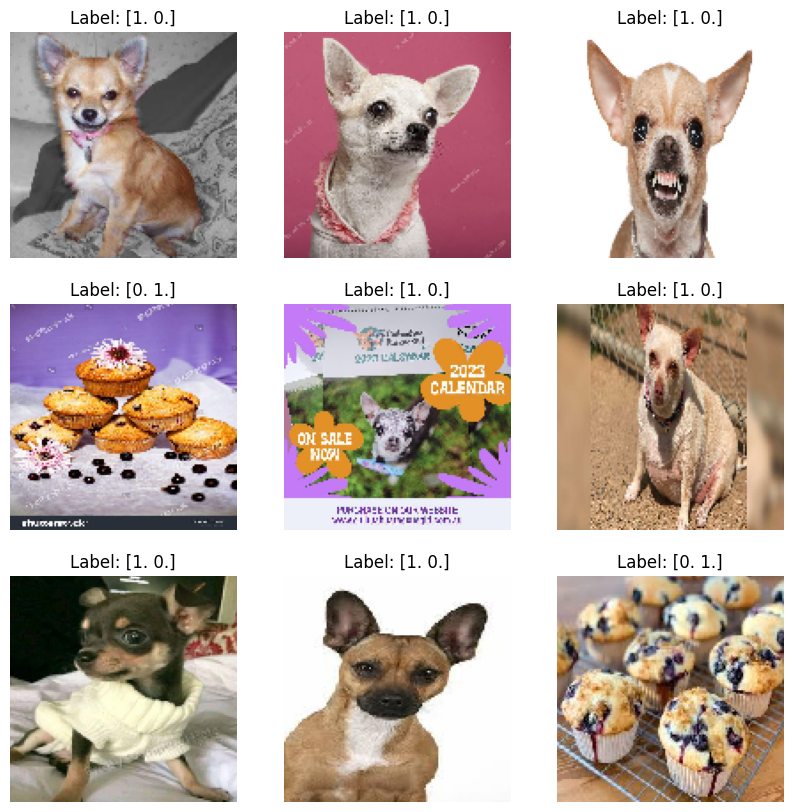

In [4]:
def visualize_batch(data):
    # Obtener un lote de imágenes y etiquetas
    images, labels = next(iter(data))  # Convertir el dataset en iterador y obtener el siguiente batch

    # Crear una cuadrícula de 3x3 para mostrar imágenes
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])  # Mostrar la imagen
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')  # Desactivar ejes
    plt.show()

# Visualizar un batch de imágenes del dataset de entrenamiento
visualize_batch(train_data)

#### Distribución de las Clases
Se visualiza la distribución de las clases para observar el balance del  y su representación en el dataset

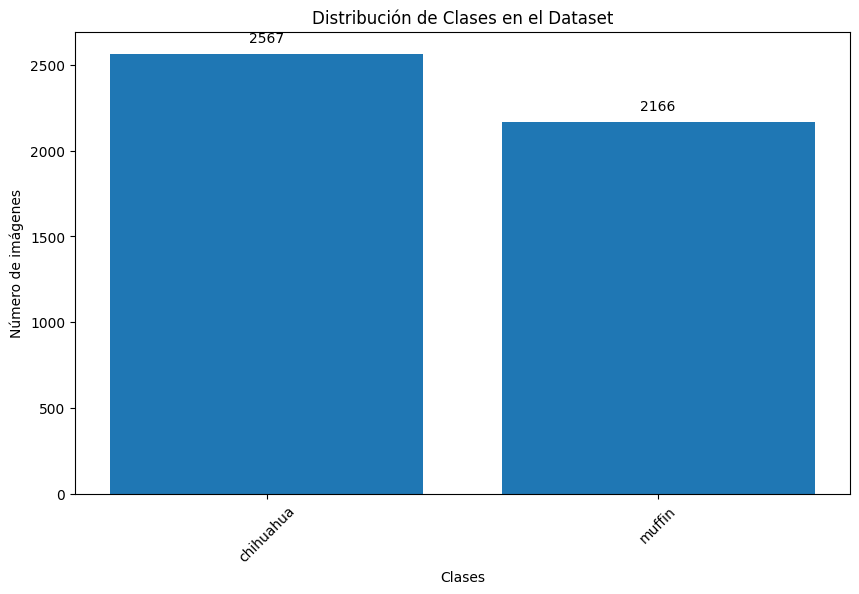

In [5]:
# Obtener los índices de las clases desde train_data
class_indices = train_data.class_indices
# Invertir el diccionario para obtener los nombres de las clases
class_names = {v: k for k, v in class_indices.items()}

# Crear una lista para los índices de clase (no one-hot)
class_indices_list = []

# Iterar sobre el dataset para extraer las etiquetas y obtener los índices de clase
for images, labels in train_data:
    # Convertir las etiquetas one-hot a índice de clase usando tf.argmax
    class_indices_list.extend(tf.argmax(labels, axis=-1).numpy())  # Añadir los índices a la lista
    if len(class_indices_list) >= len(train_data.filenames):  # Termina cuando se procesan todas las imágenes
        break

# Contar la frecuencia de cada clase
class_counts = Counter(class_indices_list)

# Graficar la distribución de clases
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names.values(), [class_counts[i] for i in range(len(class_names))])

# Añadir los totales sobre las barras
for bar, count in zip(bars, [class_counts[i] for i in range(len(class_names))]):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, str(count), ha='center', va='bottom', fontsize=10)

plt.xlabel('Clases')
plt.ylabel('Número de imágenes')
plt.title('Distribución de Clases en el Dataset')
plt.xticks(rotation=45)
plt.show()



#### Prefetch 
Para mejorar la eficiencia en el procesamiento de datos durante el entrenamiento. 

In [6]:
# Aplicar prefetch a los datos (este método optimiza la carga de datos)
train_data = tf.data.Dataset.from_generator(
    lambda: train_data,
    output_signature=(
        tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),  # Imágenes
        tf.TensorSpec(shape=(None, len(train_data.class_indices)), dtype=tf.float32)  # Etiquetas one-hot
    )
).prefetch(buffer_size=tf.data.AUTOTUNE)

test_data = tf.data.Dataset.from_generator(
    lambda: test_data,
    output_signature=(
        tf.TensorSpec(shape=(None, *IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, len(test_data.class_indices)), dtype=tf.float32)
    )
).prefetch(buffer_size=tf.data.AUTOTUNE)

## 2.- Desarrollo Modelo Perceptrón Multicapa (MLP) 

Si tienes etiquetas en formato one-hot, cambia la capa de salida a Dense(2, activation='softmax') y usa categorical_crossentropy.

In [7]:
# Crear modelo MLP
def create_mlp(input_shape):
    model = Sequential([
        Flatten(input_shape=input_shape),       # Convierte imágenes 2D en vectores 1D
        Dense(64, activation='relu'),            # Capa completamente conectada 
        Dropout(0.3),                            # Regularización para evitar sobreajuste
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(2, activation='softmax') ])         # Capa de salida para clasificación multiclase (one-hot).
    # Compilar modelo
    model.compile(
        optimizer='adam',                        # Optimizador Adam
        loss='categorical_crossentropy',         # Función de pérdida para clasificación multiclase
        metrics=['accuracy'])                  # Métrica de precisión
    return model

# Crear y visualizar el modelo MLP
mlp_model = create_mlp((128, 128, 3))  # Tamaño de entrada: imágenes redimensionadas a 128x128 con 3 canales
mlp_model.summary()                   # Resumen del modelo



c:\Users\csolis\AppData\Local\anaconda3\envs\mi_entorno\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,147,938 (12.01 MB)

 Trainable params: 3,147,938 (12.01 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Entrenar el modelo MLP
mlp_history = mlp_model.fit(
    train_data,  # Conjunto de entrenamiento
    validation_data=test_data,  # Conjunto de prueba
    epochs=10,  # Número de épocas
    verbose=1  # Imprimir progreso
)

Epoch 1/10


: 

## 3.- Desarrollo Modelo CNN


In [9]:
# Crear modelo CNN
def create_cnn(input_shape):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),  # Primera capa convolucional
        MaxPooling2D(pool_size=(2, 2)),                                  # Reducción de dimensionalidad
        BatchNormalization(),                                           # Normalización

        Conv2D(64, (3, 3), activation='relu'),                          # Segunda capa convolucional
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),

        Conv2D(128, (3, 3), activation='relu'),                         # Tercera capa convolucional
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),

        Flatten(),                                                      # Aplanar para capas densas
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')                                  # Capa de salida
    ])
    
    # Compilar el modelo
    model.compile(
        optimizer='adam', # Optimizador Adam
        loss='binary_crossentropy',  # Función de pérdida para clasificación multiclase
        metrics=['accuracy']# Métrica de precisión
    )
    return model

# Crear y visualizar el modelo CNN
cnn_model = create_cnn((128, 128, 3))
cnn_model.summary()  # Resumen del modelo

c:\Users\csolis\AppData\Local\anaconda3\envs\mi_entorno\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,953 (24.99 MB)

 Trainable params: 6,549,505 (24.98 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Entrenar el modelo CNN
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    verbose=1
)

#### 4. Comparación de metricas

In [13]:
# Evaluar el modelo en el conjunto de prueba
score = model.evaluate(test_dataset, verbose=1)

# Imprimir los resultados
print('Test loss:', score[0])  # Pérdida en el conjunto de prueba
print('Test accuracy:', score[1])  # Precisión en el conjunto de prueba


37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7652 - loss: 2.7975
Test loss: 3.421673059463501
Test accuracy: 0.7592905163764954


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


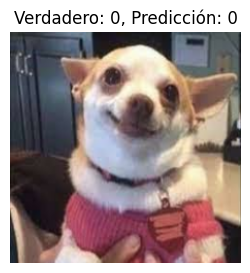

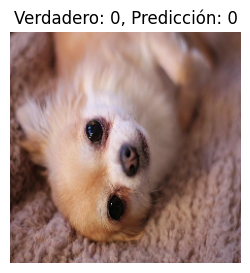

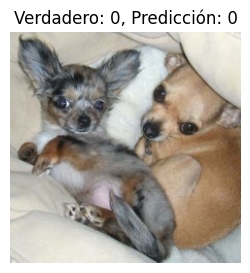

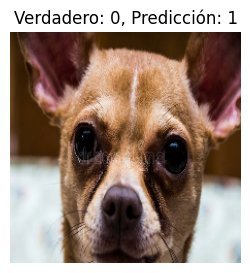

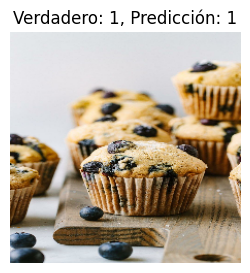

In [14]:
# Obtener las imágenes y las etiquetas verdaderas
images, labels = next(iter(test_dataset))

# Hacer predicciones sobre el batch de imágenes
predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)  # Obtener las clases predichas

# Obtener las clases verdaderas del conjunto de prueba
true_classes = np.argmax(labels.numpy(), axis=1)

# Mostrar las primeras 5 imágenes con sus etiquetas verdaderas y predichas
for i in range(5):
    plt.figure(figsize=(3, 3))
    
    # Mostrar la imagen
    plt.imshow(images[i].numpy().astype("uint8"))
    
    # Título con las etiquetas
    plt.title(f"Verdadero: {true_classes[i]}, Predicción: {predicted_classes[i]}")
    
    plt.axis('off')  # Sin ejes
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

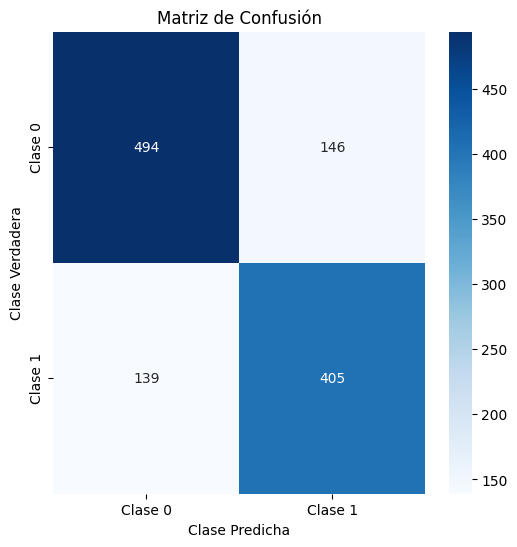

In [15]:
# Inicializar listas para almacenar las clases verdaderas y predichas
true_classes = []
predicted_classes = []

# Iterar sobre el conjunto de datos de prueba
for images, labels in test_dataset:
    # Hacer predicciones sobre el batch de imágenes
    predictions = model.predict(images)
    predicted_classes.extend(np.argmax(predictions, axis=1))  # Acumular las predicciones
    true_classes.extend(np.argmax(labels, axis=1))  # Acumular las etiquetas verdaderas

# Generar la matriz de confusión
cm = confusion_matrix(true_classes, predicted_classes)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
plt.ylabel("Clase Verdadera")
plt.xlabel("Clase Predicha")
plt.title("Matriz de Confusión")
plt.show()



MLP

In [48]:
# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = model_mlp.evaluate(test_dataset, verbose=2)

print(f"\nPrecisión en el conjunto de prueba: {test_acc * 100:.2f}%")


37/37 - 4s - 104ms/step - accuracy: 0.7416 - loss: 2.1384

Precisión en el conjunto de prueba: 74.16%


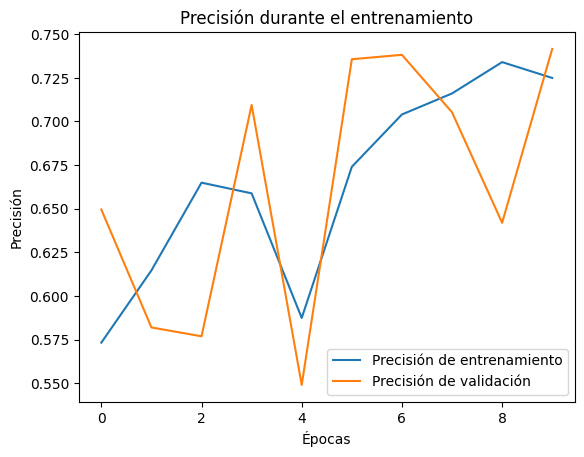

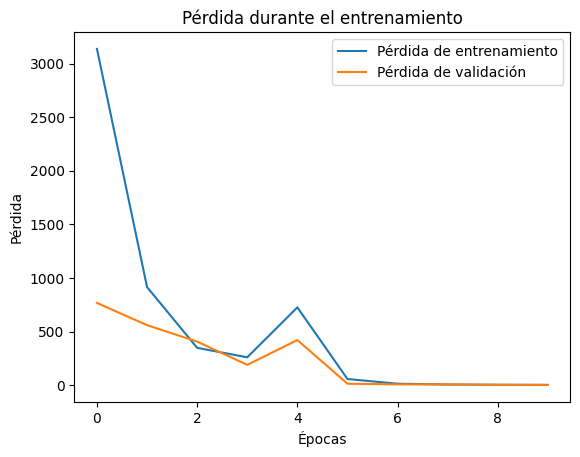

In [49]:
# Graficar precisión de entrenamiento y validación
plt.plot(history_mlp.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history_mlp.history['val_accuracy'], label='Precisión de validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.title('Precisión durante el entrenamiento')
plt.show()

# Graficar pérdida de entrenamiento y validación
plt.plot(history_mlp.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history_mlp.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.title('Pérdida durante el entrenamiento')
plt.show()


37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step


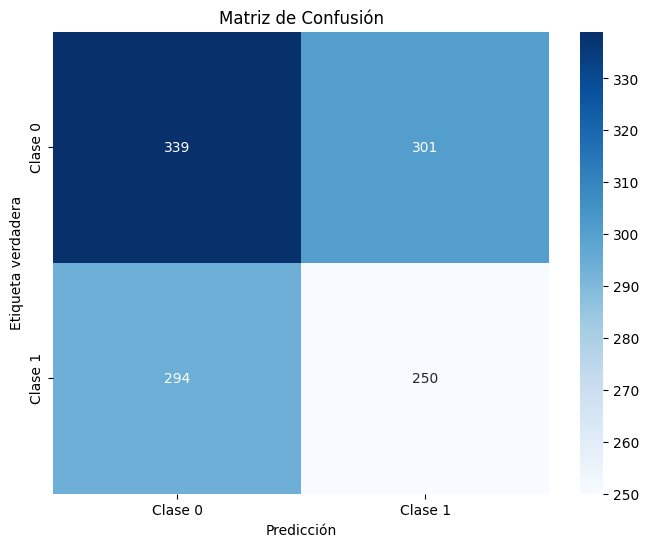

In [50]:
# Predecir etiquetas para el conjunto de prueba
y_pred_probs = model.predict(test_dataset)  # Probabilidades predichas
y_pred = np.argmax(y_pred_probs, axis=1)    # Convertir a etiquetas categóricas

# Extraer etiquetas reales del conjunto de prueba
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_dataset])

# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de Confusión")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


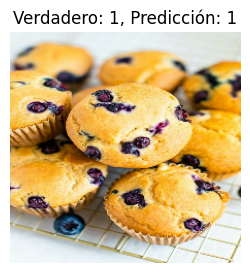

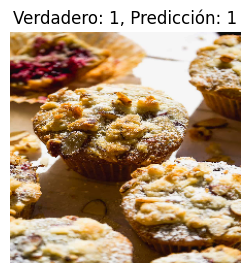

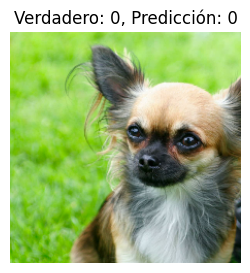

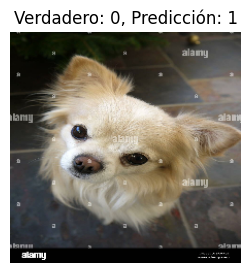

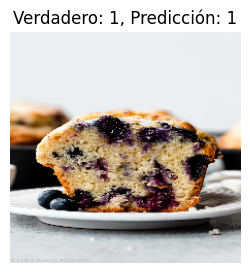

In [53]:
# Obtener las imágenes y las etiquetas verdaderas
images, labels = next(iter(test_dataset))

# Hacer predicciones sobre el batch de imágenes
predictions = model_mlp.predict(images)
predicted_classes = np.argmax(predictions, axis=1)  # Obtener las clases predichas

# Obtener las clases verdaderas del conjunto de prueba
true_classes = np.argmax(labels.numpy(), axis=1)

# Mostrar las primeras 5 imágenes con sus etiquetas verdaderas y predichas
for i in range(5):
    plt.figure(figsize=(3, 3))
    
    # Mostrar la imagen
    plt.imshow(images[i].numpy().astype("uint8"))
    
    # Título con las etiquetas
    plt.title(f"Verdadero: {true_classes[i]}, Predicción: {predicted_classes[i]}")
    
    plt.axis('off')  # Sin ejes
    plt.show()